### Beyond Pace: Pace-Driven Running vs Navigation-Driven Sports 
##### Part 3 - ML

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

C:\Users\viver\AppData\Local\Temp\ipykernel_15180\1573075633.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df_combined = pd.read_csv("../data/processed/garmin_combined.csv")

In [3]:
# після read_csv Date тип знову став object, переводимо:

df_combined["Date"] = pd.to_datetime(df_combined["Date"])

In [4]:
# Беремо тільки рядки без NaN в потрібних колонках:

df_ml = df_combined[["Avg HR", "Avg Pace num", "Total Ascent"]].dropna()

##### Form a set of input features for the models:

X — Can the average heart rate be explained by the average pace and altitude gain?

y — What will the average heart rate be if we know the pace and altitude gain?

In [5]:
# X — це ознаки, фактори, незалежні змінні - це причини, пояснювальні фактори
# y — це цільова змінна, target, dependent variable - це результат, який прогнозуємо

X = df_ml[["Avg Pace num", "Total Ascent"]]
y = df_ml["Avg HR"]

##### Let's split the data into train and test:

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##### Now the prediction and assessment:

In [8]:
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred).round(3))
print("MAE:", mean_absolute_error(y_test, y_pred).round(2))

R²: 0.117
MAE: 15.73


R² and MAE are model quality metrics.
R² shows what share of the target variable's variation the model was able to explain.
Our target is y = Avg HR, meaning the model predicts heart rate from
X = Avg Pace num + Total Ascent.

The R² of 0.117 tells us the model is weak — pace and elevation explain
only about 12% of why heart rate changes.

MAE shows the average prediction error. Since our target is Avg HR,
MAE is measured in beats per minute. Our model is off by ~16 bpm on average.

But this is actually expected in our case. In navigation-driven sports,
heart rate depends on more than just pace and elevation — it is also shaped
by course technicality, navigation stops, fatigue, weather, terrain surface,
and even equipment issues.

A weak model here is not a failure — it is a finding.
It confirms that heart rate in navigation-driven sports cannot be predicted
from pace and elevation alone.

##### Let's look at the model coefficients:

In [9]:
print("Коефіцієнти:")
print(f"Avg Pace num: {model.coef_[0]:.3f}")
print(f"Total Ascent: {model.coef_[1]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")

Коефіцієнти:
Avg Pace num: -1.876
Total Ascent: 0.004
Intercept: 155.046


Intercept = 155 is the baseline value the model starts from when
Avg Pace num = 0 and Total Ascent = 0. This is not a realistic scenario,
but the model needs it as a starting point.

Avg Pace num = -1.88 means that with Total Ascent held constant,
each 1 min/km increase in pace predicts a drop of 1.88 bpm in heart rate.
This makes sense for road running — slower pace, lower effort, lower HR.
But not always in orienteering or ARDF. There, a slow pace may mean
navigating through dense forest, reading a map, crossing a swamp,
or searching for a checkpoint — not easy effort.

Total Ascent = -0.004 means that with Avg Pace num held constant,
each 100m increase in elevation gain predicts a drop of 0.4 bpm.
This seems counterintuitive — climbs should raise heart rate.
A few possible explanations: Total Ascent does not account for distance —
300m of climb over 5km is very different from 300m over 25km.
Also, elevation may slow movement without raising HR — in navigation-driven
sports, an athlete may walk a climb while reading a map, keeping HR stable.
The weak R² also suggests the model simply cannot capture this relationship well.

Overall, a weak model here was predictable — the correlation matrix already
hinted at it. But that is exactly the point of this project: standard metrics
used to evaluate traditional runners are not adequate for navigation-driven athletes.
Heart rate cannot be predicted from pace and elevation alone —
and that confirms that these metrics are insufficient to describe
what is really happening in navigation-driven sports.

That is why this project is called Beyond Pace.

##### Visualize the results:

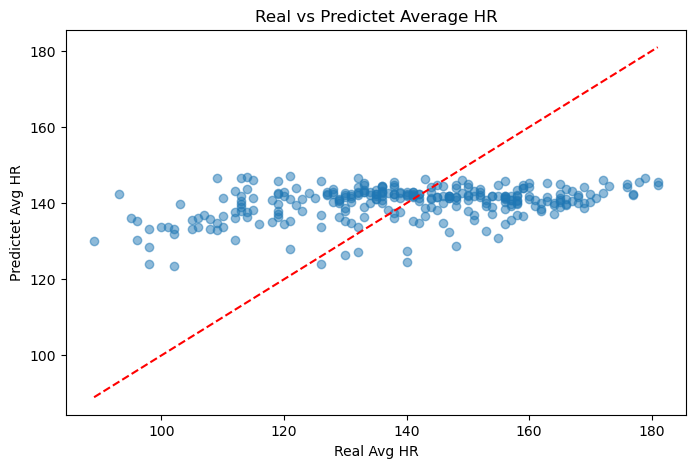

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real Avg HR")
plt.ylabel("Predictet Avg HR")
plt.title("Real vs Predictet Average HR")

plt.savefig("../images/ML_Real_vs_PredictetAvgHR.png", dpi=300, bbox_inches="tight")
plt.show()

This is a visual confirmation of R² = 0.117. The points are scattered and do not
follow the red line — the model is missing. If the model were perfect, all points
would lie exactly on the red dashed line, which represents the ideal prediction
where "real = predicted."

Notice that most predictions cluster around 135–145 bpm regardless of the actual
heart rate. The model essentially predicts a near-constant value — it cannot
capture the real variation in HR across athletes and activity types.

This project successfully demonstrated the fundamental difference between
pace-driven running and navigation-driven sports:

Pace-driven running focuses on pace, distance, speed, and consistency —
metrics that are stable, predictable, and well-captured by standard models.

Navigation-driven sports depend not only on physical speed, but on route choice,
map reading, terrain, split-second decisions — and sometimes technical factors
like signal strength or equipment failure.

Standard running metrics are not enough to describe navigation-driven athletes.
That is what Beyond Pace set out to show — and the data confirmed it.